# EDA – E-commerce Fraud Data

This notebook explores the Fraud_Data.csv dataset to understand patterns,
class imbalance, and features relevant to fraud detection.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")


In [7]:
df = pd.read_csv("../data/raw/Fraud_Data.csv")
df.head()


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [8]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df['ip_address'] = df['ip_address'].astype(int)


In [9]:
class_counts = df['class'].value_counts()
class_ratio = df['class'].value_counts(normalize=True)

class_counts, class_ratio


(class
 0    136961
 1     14151
 Name: count, dtype: int64,
 class
 0    0.906354
 1    0.093646
 Name: proportion, dtype: float64)

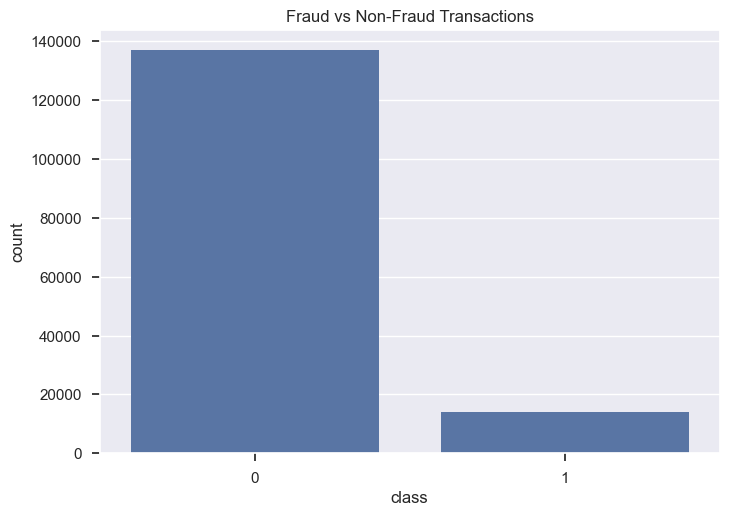

In [10]:
sns.countplot(x='class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


The dataset is highly imbalanced, with fraudulent transactions representing
a very small percentage of the total transactions. This confirms the need
for specialized evaluation metrics and resampling techniques.


## Purchase Value Distribution


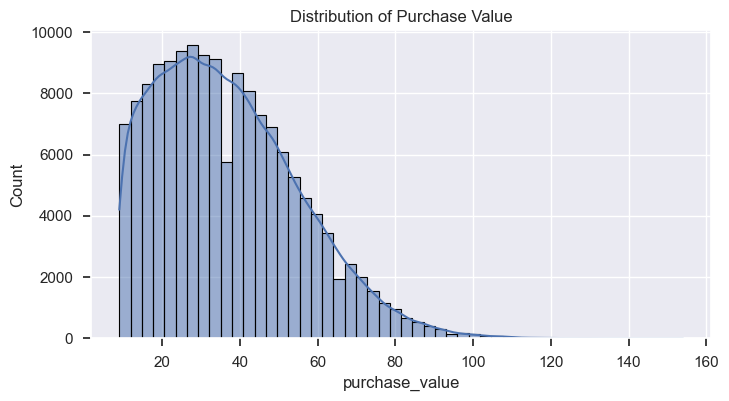

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df['purchase_value'], bins=50, kde=True)
plt.title("Distribution of Purchase Value")
plt.show()


Most transactions have relatively low purchase values, with a long tail of
high-value transactions, which may indicate higher fraud risk.

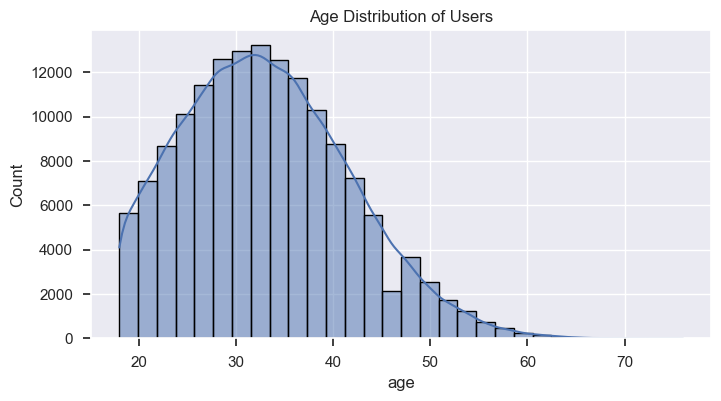

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution of Users")
plt.show()


Fraudulent activity may vary across age groups, making age a useful
supporting feature for fraud detection.

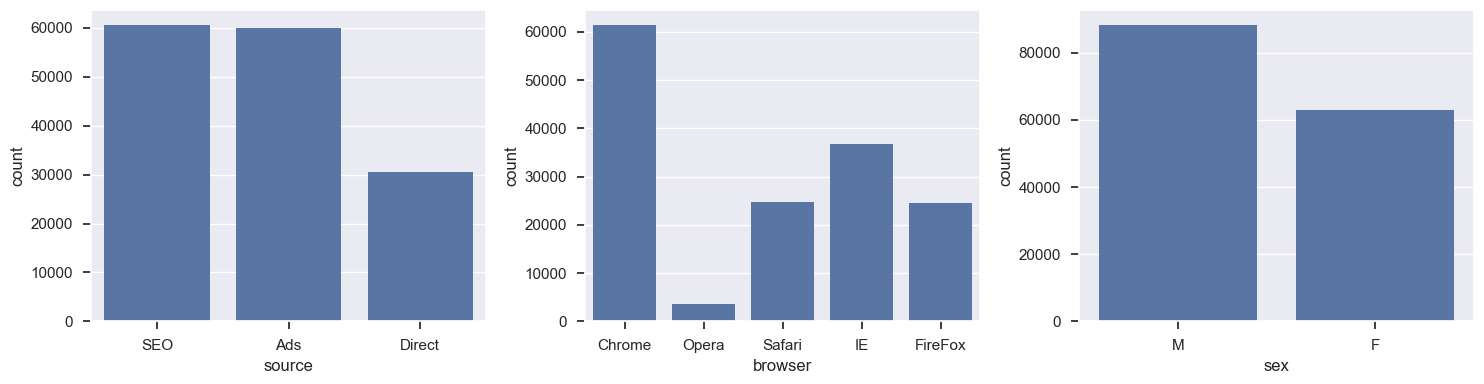

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(ax=axes[0], x='source', data=df)
sns.countplot(ax=axes[1], x='browser', data=df)
sns.countplot(ax=axes[2], x='sex', data=df)

plt.tight_layout()
plt.show()


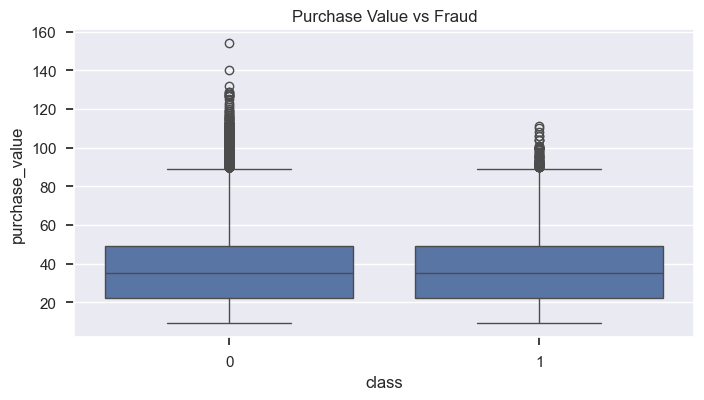

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(x='class', y='purchase_value', data=df)
plt.title("Purchase Value vs Fraud")
plt.show()


In [ ]:
Fraudulent transactions tend to have higher median purchase values,
suggesting fraudsters attempt larger transactions.


In [17]:
df['time_since_signup'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds() / 3600


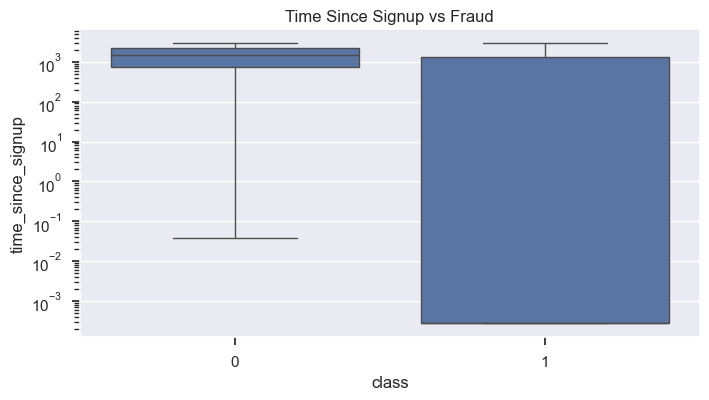

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(x='class', y='time_since_signup', data=df)
plt.yscale("log")
plt.title("Time Since Signup vs Fraud")
plt.show()


Fraudulent transactions frequently occur shortly after account creation,
highlighting early user activity as a strong fraud signal.


In [19]:
fraud_rate_source = df.groupby('source')['class'].mean().sort_values(ascending=False)
fraud_rate_source


source
Direct    0.105370
Ads       0.092066
SEO       0.089285
Name: class, dtype: float64

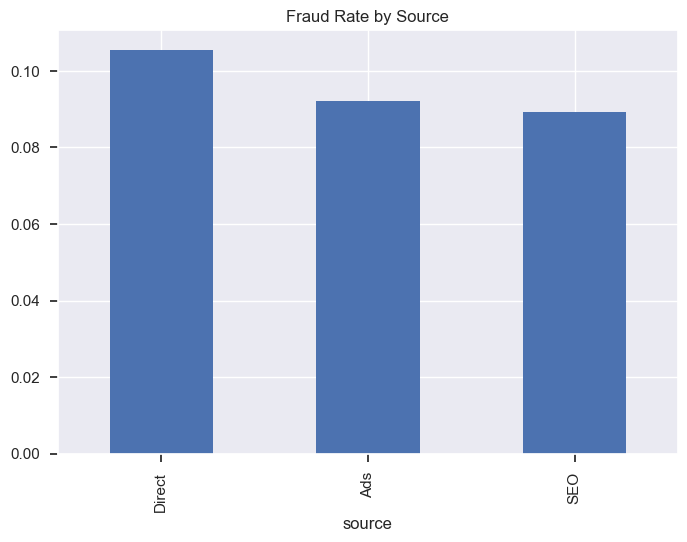

In [20]:
fraud_rate_source.plot(kind='bar', title='Fraud Rate by Source')
plt.show()
